In [ ]:
import sys, json, math, torch, os
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image

import numpy as np

import scanpy as sc
import pandas as pd
from utils_istar import load_pickle, save_image, read_lines, load_image
from scipy.stats import pearsonr

from SPHERE.utils import build_counts
from step2 import align_tensor
from matplotlib_init import plt, sns


/cluster/home/bqhu_jh/share/miniconda3/envs/omni/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


# 1. HIPT 结果在 

`/cluster/home/panfy/projects/panlab/analysis/istar/hipt_result/{sample}/{gene}.pickle`

Pickle loaded from /cluster/home/panfy/projects/panlab/analysis/istar//hipt_result/NCBI783/GATA3.pickle


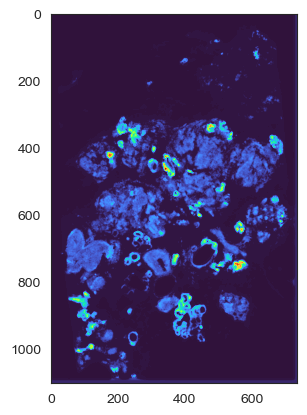

In [ ]:
sample='NCBI783'
prefix='/cluster/home/panfy/projects/panlab/analysis/istar/'
gene='GATA3'
cnts = load_pickle(f'{prefix}/hipt_result/{sample}/{gene}.pickle')
plt.imshow(cnts, cmap='turbo')

# 2. Expression ground truth

`/cluster/home/panfy/projects/panlab/data/hest/hest_lib/transcripts/{sample}_transcripts.parquet`

In [27]:
def get_tensor_ref_exp(sample, module, patch=256):
    prefix=f'/cluster/home/panfy/projects/panlab/analysis/istar/mliti-result/auto_ratio/{sample}/{module}/'
    os.chdir(prefix)
    adata=sc.read(f'/cluster/home/panfy/projects/panlab/analysis/istar/HD_module_extracted_feature/{sample}/{module}/20x_{patch}px_0px_overlap/attention_features_{module}/{sample}_flatten.h5ad')
    transcripts_path = '/cluster/home/panfy/projects/panlab/data/hest/hest_lib/transcripts/'
    transcripts_path = transcripts_path + sample + '_transcripts.parquet'
    transcripts = pd.read_parquet(transcripts_path)
    side=38
    min_x=adata.obsm['spatial'][:,0].min()-side/2
    max_x=adata.obsm['spatial'][:,0].max()+side/2
    min_y=adata.obsm['spatial'][:,1].min()-side/2
    max_y=adata.obsm['spatial'][:,1].max()+side/2
    transcripts = transcripts[(transcripts['he_x'] >= min_x) & (transcripts['he_x'] <= max_x) & 
                    (transcripts['he_y'] >= min_y) & (transcripts['he_y'] <= max_y)]
    gene_list='/cluster/home/panfy/projects/panlab/data/hest/eval/bench_data/IDC/var_50genes.json'
    with open(gene_list, 'r') as f:
        genes = json.load(f)['genes']
    transcripts['feature_name']=transcripts['feature_name'].str.decode('utf-8')
    transcripts=transcripts.loc[transcripts['feature_name'].isin(genes)]
    mtx1=build_counts(min_x,max_x,min_y,max_y,side,genes,transcripts)
    img = load_image('he.jpg')
    img_array = np.array(img)
    tensor1=torch.from_numpy(mtx1)
    tensor_ref_exp=tensor1.permute(2, 1, 0).unsqueeze(0).float()
    tensor_ref_exp=align_tensor(tensor_ref_exp,img_array)
    tensor_ref_exp=tensor_ref_exp.squeeze(0)
    return tensor_ref_exp

sample='NCBI783'
module='uni_v1'
patch=256
tensor_ref_exp = get_tensor_ref_exp(sample, module, patch)
tensor_ref_exp_virchow = get_tensor_ref_exp(sample, "virchow", patch)
plt.imshow(tensor_ref_exp[0, :, :].detach().numpy(), cmap='turbo')

Processing genes: 100%|██████████| 50/50 [00:18<00:00,  2.74it/s]


Image loaded from he.jpg


KeyboardInterrupt: 

In [ ]:


# prefix=f'/cluster/home/panfy/projects/panlab/analysis/istar/mliti-result/auto_ratio/{sample}/{module}/'
# os.chdir(prefix)
# adata=sc.read(f'/cluster/home/panfy/projects/panlab/analysis/istar/HD_module_extracted_feature/{sample}/{module}/20x_{patch}px_0px_overlap/attention_features_{module}/{sample}_flatten.h5ad')
# transcripts_path = '/cluster/home/panfy/projects/panlab/data/hest/hest_lib/transcripts/'
# transcripts_path = transcripts_path + sample + '_transcripts.parquet'
# transcripts = pd.read_parquet(transcripts_path)
# side=38
# min_x=adata.obsm['spatial'][:,0].min()-side/2
# max_x=adata.obsm['spatial'][:,0].max()+side/2
# min_y=adata.obsm['spatial'][:,1].min()-side/2
# max_y=adata.obsm['spatial'][:,1].max()+side/2
# transcripts = transcripts[(transcripts['he_x'] >= min_x) & (transcripts['he_x'] <= max_x) & 
#                 (transcripts['he_y'] >= min_y) & (transcripts['he_y'] <= max_y)]
gene_list='/cluster/home/panfy/projects/panlab/data/hest/eval/bench_data/IDC/var_50genes.json'
with open(gene_list, 'r') as f:
    genes = json.load(f)['genes']
# transcripts['feature_name']=transcripts['feature_name'].str.decode('utf-8')
# transcripts=transcripts.loc[transcripts['feature_name'].isin(genes)]
# mtx1=build_counts(min_x,max_x,min_y,max_y,side,genes,transcripts)
# img = load_image('he.jpg')
# img_array = np.array(img)
# tensor1=torch.from_numpy(mtx1)
# tensor_ref_exp=tensor1.permute(2, 1, 0).unsqueeze(0).float()
# tensor_ref_exp=align_tensor(tensor_ref_exp,img_array)
# tensor_ref_exp=tensor_ref_exp.squeeze(0)

In [ ]:
from scipy.stats import spearmanr
prefix='/cluster/home/panfy/projects/panlab/analysis/istar/'
results = []
for gene in genes:
    cnts = load_pickle(f'{prefix}/hipt_result/{sample}/{gene}.pickle', verbose=False)
    a = cnts
    b = tensor_ref_exp[genes.index(gene),:,:].numpy()
    common = (a.flatten() > 0.1) & (b.flatten() > 0.1)
    corr , _= pearsonr(a.flatten()[common], b.flatten()[common])
    corr_sp, _ = spearmanr(a.flatten()[common], b.flatten()[common])
    results.append({
        'gene': gene,
        'pearson': corr,
        'spearman': corr_sp,
    })

df = pd.DataFrame(results)
print(df["pearson"].mean(), df["spearman"].mean())
df

0.4552940280149955 0.39792941734702664


,gene,pearson,spearman
0,ABCC11,0.722361,0.762705
1,ADH1B,0.230313,0.194979
2,ADIPOQ,0.240456,0.152094
3,ANKRD30A,0.451312,0.493974
4,AQP1,0.389271,0.336621
5,AQP3,0.405553,0.392341
6,CCR7,0.349782,0.303405
7,CD3E,0.602350,0.520840
8,CEACAM6,0.468016,0.396936
9,CEACAM8,0.087545,0.045768


# 3. Univ1 feature

Pickle loaded from /cluster/home/panfy/projects/panlab/analysis/istar/mliti-result/auto_ratio/NCBI783/uni_v1/cnts-super/KLF5.pickle


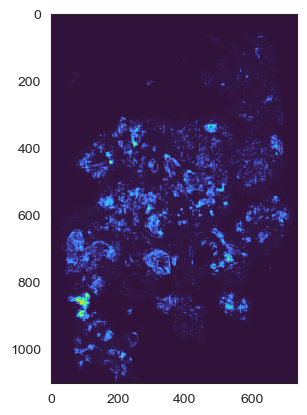

In [ ]:
prefix=f'/cluster/home/panfy/projects/panlab/analysis/istar/mliti-result/auto_ratio/{sample}/{module}/'
gene='KLF5'
cnts = load_pickle(f'{prefix}cnts-super/{gene}.pickle')
plt.imshow(cnts, cmap='turbo')

In [ ]:
dict_ref = {}
for module in ['hipt', 'conch_v1', 'conch_v15', 'gigapath', 'uni_v1', 'virchow']:
    # model_ref = module if module != 'hipt' else 'uni_v1'
    # tensor_ref_exp = get_tensor_ref_exp(sample, model_ref, patch)
    dict_ref[module] = tensor_ref_exp

In [ ]:
from pytorch_msssim import ssim
from scipy.stats import spearmanr
import cv2

def ssim_loss(predicted_image, ground_truth_image):
    LD_SSIM = 1 - ssim(predicted_image, ground_truth_image,
                           data_range=1, size_average=True)
    return LD_SSIM

def dice_loss(input, target):
    """
    Calculate Dice Loss

    Args:
        input (torch.Tensor): A binary tensor of shape (H, W)
        target (torch.Tensor): A binary tensor of shape (H, W)

    Return:
        torch.Tensor: A scalar tensor representing the Dice loss.
    """
    assert input.size() == target.size(), "Input and target masks should have the same shape"

    input_flat = input.view(-1)
    target_flat = target.view(-1)

    intersection = (input_flat * target_flat).sum()
    dice_score = (2. * intersection + 1.) / (input_flat.sum() + target_flat.sum() + 1.)
    dice_loss_ = 1 - dice_score

    return dice_loss_


In [ ]:
prefix='/cluster/home/panfy/projects/panlab/analysis/istar/'
results = []
file_predict = "%s/hipt_result/%s/predict.json" % (prefix, sample)
gene_list='/cluster/home/panfy/projects/panlab/data/hest/eval/bench_data/IDC/var_50genes.json'
with open(gene_list, 'r') as f:
    genes = json.load(f)['genes']

for module in ['hipt', 'conch_v1', 'conch_v15', 'gigapath', 'uni_v1', 'virchow']:
    if module not in dict_ref:
        model_ref = module if module != 'hipt' else 'uni_v1'
        dict_ref[module] = get_tensor_ref_exp(sample, model_ref, patch)
        
    tensor_ref_exp = dict_ref[module]
    for gene in tqdm(genes, desc=f'Processing {module}'):
        file_predict=f'{prefix}/mliti-result/auto_ratio/{sample}/{module}/cnts-super/{gene}.pickle'
        if module == "hipt":
            file_predict = f'{prefix}/hipt_result/{sample}/{gene}.pickle'

        
        
        tensor_predict_exp = load_pickle(file_predict, verbose=False)
        a = tensor_predict_exp
        b = tensor_ref_exp[genes.index(gene),:,:].numpy()
        a = cv2.GaussianBlur(a, (5, 5), 10, 10)
        b = cv2.GaussianBlur(b, (5, 5), 10, 10)
        corr , _= pearsonr(a.flatten(), b.flatten())
        corr_sp, _ = spearmanr(a.flatten(), b.flatten())
        cos_sim = F.cosine_similarity(torch.from_numpy(a).unsqueeze(0), torch.from_numpy(b).unsqueeze(0), dim=0).mean()
        dice_ = dice_loss(torch.from_numpy(a).unsqueeze(0), torch.from_numpy(b).unsqueeze(0))
        ssim_ = ssim_loss(torch.from_numpy(a).unsqueeze(0).unsqueeze(0), torch.from_numpy(b).unsqueeze(0).unsqueeze(0))
        
        results.append({
            'sample': sample,
            'gene': gene,
            'model': module,
            'pearson': corr,
            'spearman': corr_sp,
            "cos_sim": cos_sim.item(),
            "dice": dice_.item(),
            "ssim": ssim_.item(),
        })

df = pd.DataFrame(results)
print(df["pearson"].mean(), df["spearman"].mean())
df

Processing hipt:   0%|          | 0/50 [00:00<?, ?it/s]

Processing virchow: 100%|██████████| 50/50 [00:24<00:00,  2.06it/s]

0.7783270277600144 0.62976738928573


,sample,gene,model,pearson,spearman,cos_sim,dice,ssim
0,NCBI783,ABCC11,hipt,0.931683,0.653074,0.365077,-6.412145,0.741528
1,NCBI783,ADH1B,hipt,0.650228,0.614090,0.404077,0.642864,0.775322
2,NCBI783,ADIPOQ,hipt,0.517544,0.335996,0.186607,0.823613,0.618442
3,NCBI783,ANKRD30A,hipt,0.838755,0.704693,0.401471,-1.408423,0.677753
4,NCBI783,AQP1,hipt,0.713093,0.698058,0.478263,-0.702696,0.752140
...,...,...,...,...,...,...,...,...
295,NCBI783,TENT5C,virchow,0.688715,0.760164,0.379993,0.499182,0.741060
296,NCBI783,TOP2A,virchow,0.740957,0.665828,0.324021,-0.391203,0.711325
297,NCBI783,TPSAB1,virchow,0.462958,0.376449,0.110201,0.897367,0.331951
298,NCBI783,TRAC,virchow,0.875722,0.815745,0.446215,-0.927631,0.857543


In [ ]:
df_melt = pd.melt(df, id_vars=['sample', 'gene', 'model'])
df_score = pd.pivot_table(df_melt, index=['model'],columns='variable', values='value').reset_index().sort_values(['spearman'], ascending=True)
df_score

variable,model,cos_sim,dice,pearson,spearman,ssim
3,hipt,0.310545,-1.175743,0.779564,0.614620,0.619823
0,conch_v1,0.310545,-1.177221,0.781685,0.625167,0.652301
5,virchow,0.310545,-1.100841,0.763018,0.629500,0.683004
1,conch_v15,0.310545,-1.184175,0.780012,0.630493,0.656293
2,gigapath,0.310545,-1.145221,0.777815,0.636912,0.663212
4,uni_v1,0.310545,-1.196810,0.787868,0.641912,0.649960


<Axes: xlabel='variable', ylabel='value'>

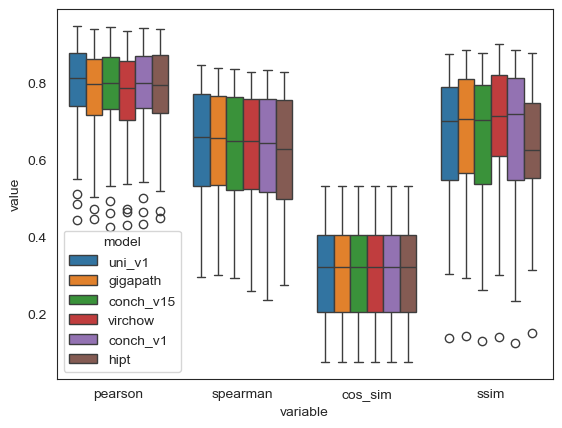

In [ ]:

sns.boxplot(data=df_melt[df_melt["variable"]!="dice"], x='variable', y='value', hue='model', hue_order=df_score["model"][::-1])


# 4. Visualize single gene

In [28]:
prefix='/cluster/home/panfy/projects/panlab/analysis/istar/'
genes

['ABCC11',
 'ADH1B',
 'ADIPOQ',
 'ANKRD30A',
 'AQP1',
 'AQP3',
 'CCR7',
 'CD3E',
 'CEACAM6',
 'CEACAM8',
 'CLIC6',
 'CYTIP',
 'DST',
 'ERBB2',
 'ESR1',
 'FASN',
 'GATA3',
 'IL2RG',
 'IL7R',
 'KIT',
 'KLF5',
 'KRT14',
 'KRT5',
 'KRT6B',
 'MMP1',
 'MMP12',
 'MS4A1',
 'MUC6',
 'MYBPC1',
 'MYH11',
 'MYLK',
 'OPRPN',
 'OXTR',
 'PIGR',
 'PTGDS',
 'PTN',
 'PTPRC',
 'SCD',
 'SCGB2A1',
 'SERHL2',
 'SERPINA3',
 'SFRP1',
 'SLAMF7',
 'TACSTD2',
 'TCL1A',
 'TENT5C',
 'TOP2A',
 'TPSAB1',
 'TRAC',
 'VWF']

In [32]:
def comparing_gene(gene, module="hipt", tensor_ref_exp=None):
    if tensor_ref_exp is None:
        tensor_ref_exp = get_tensor_ref_exp(sample, model_ref, patch)
    
    file_predict=f'{prefix}/mliti-result/auto_ratio/{sample}/{module}/cnts-super/{gene}.pickle'
    if module == "hipt":
        file_predict = f'{prefix}/hipt_result/{sample}/{gene}.pickle'

    tensor_predict_exp = load_pickle(file_predict, verbose=False)
    np_predict_exp = cv2.GaussianBlur(tensor_predict_exp, (5, 5), 10, 10)
    np_ref_exp = cv2.GaussianBlur(tensor_ref_exp[genes.index(gene),:,:].numpy(), (5, 5), 10, 10)
    return np_predict_exp, np_ref_exp


# l_ref = []
# l_hipt = []
# l_pred = []
# for gene in genes:
#     np_pred, np_ref = comparing_gene(gene, module='hipt', tensor_ref_exp=dict_ref['hipt'])
#     np_pred_gigapath, _ = comparing_gene(gene, module='virchow', tensor_ref_exp=dict_ref['virchow'])
#     l_ref.append(np_ref)
#     l_hipt.append(np_pred)
#     l_pred.append(np_pred_gigapath)
# gene = "KLF5"
# gene = "GATA3"
gene = "CD3E"
module = "uni_v1"
np_pred, np_ref = comparing_gene(gene, module='hipt', tensor_ref_exp=dict_ref['hipt'])
np_pred_gigapath, _ = comparing_gene(gene, module=module, tensor_ref_exp=dict_ref[module])
    

In [33]:
# np_ref_HWC = np.stack(l_ref, axis=0)
# np_hipt_HWC = np.stack(l_hipt, axis=0)
# np_pred_HWC = np.stack(l_pred, axis=0)

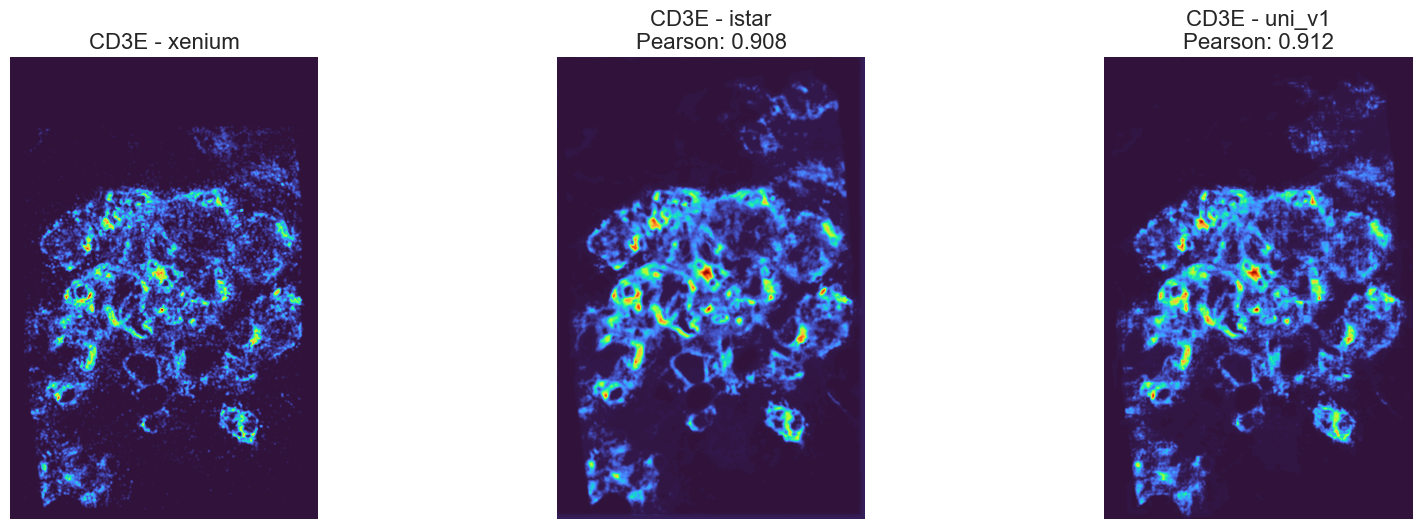

In [35]:
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(1, 3, 1)
ax.imshow(np_ref, cmap='turbo')
ax.set_axis_off()
ax.set_title(f'{gene} - xenium', fontsize=16)

ax = fig.add_subplot(1, 3, 2)
ax.imshow(np_pred, cmap='turbo')
ax.set_axis_off()
ax.set_title(f'{gene} - istar\nPearson: {pearsonr(np_ref.flatten(), np_pred.flatten())[0]:.3f}', fontsize=16)



ax = fig.add_subplot(1, 3, 3)
ax.imshow(np_pred_gigapath, cmap='turbo')
ax.set_title(f'{gene} - {module}\nPearson: {pearsonr(np_ref.flatten(), np_pred_gigapath.flatten())[0]:.3f}', fontsize=16)
ax.set_axis_off()

In [111]:
np_pred_gigapath.min()

0.0009754061

In [ ]:
uni_v1
side19.5=0.42010847136366514
side39=0.4279843284995481
side38=0.5433012633256713

hipt=0.5607903765307463

In [ ]:
gigapath
side19.5=0.40312332420214814
side39=0.42009041961475296
side38=0.521059094400012

hipt=0.5607903765307463

In [ ]:
conch_v1
side9=0.27134033219674
side18=0.3829110815810197
side36=0.31463191068838176
side38=0.4837950883309052

hipt=0.5607903765307463

In [ ]:
conch_v15
side9=0.2770167651851921
side18=0.39183387138820713
side36=0.32892086276663834
side38=0.49662696899051034

hipt=0.5607903765307463

In [ ]:
virchow
side32=0.34365010223445147
side34=0.34109271106942674
side36=0.34158055984289015
side37=0.43317954535417996
side38=0.4936188903435816
side39=0.4163274946323698

hipt=0.4452808053088076

In [95]:
adata=sc.read('/cluster/home/panfy/projects/panlab/analysis/istar/express_adata/patch256/adata/NCBI783.h5ad')